# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis
**Name:** [Your Name] | **Course:** MSCS 634 | 

**Dataset:** Weather Data from Kaggle (https://www.kaggle.com/datasets/rohitgrewal/weather-data)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

## Step 1: Data Collection

In [35]:
df = pd.read_csv('/kaggle/input/datasets/rohitgrewal/weather-data/Project 1 - Weather Dataset.csv')
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
print("First five rows:")
df.head()

First five rows:


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


## Step 2: Data Visualization

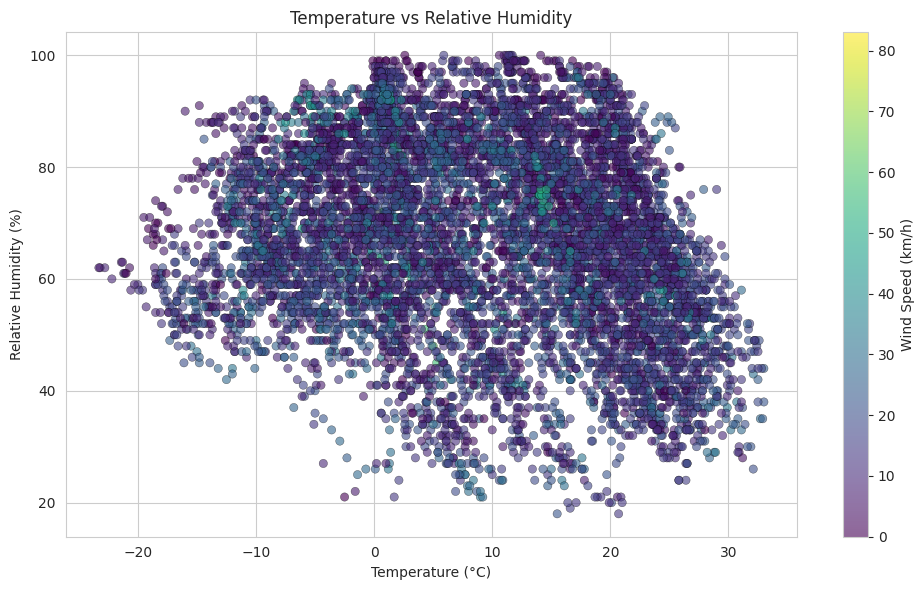

(None, None)

In [36]:
# Scatter Plot: Temperature vs Humidity colored by Wind Speed
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Temp_C'], df['Rel Hum_%'], c=df['Wind Speed_km/h'], 
                     cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Wind Speed (km/h)')
plt.xlabel('Temperature (°C)'), plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Relative Humidity')
plt.tight_layout(), plt.show()
# Insight: Inverse relationship between temperature and humidity; moderate temps show wide humidity range.

/tmp/ipykernel_57/451501702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather', y='Temp_C', data=df_top, palette='Set3')


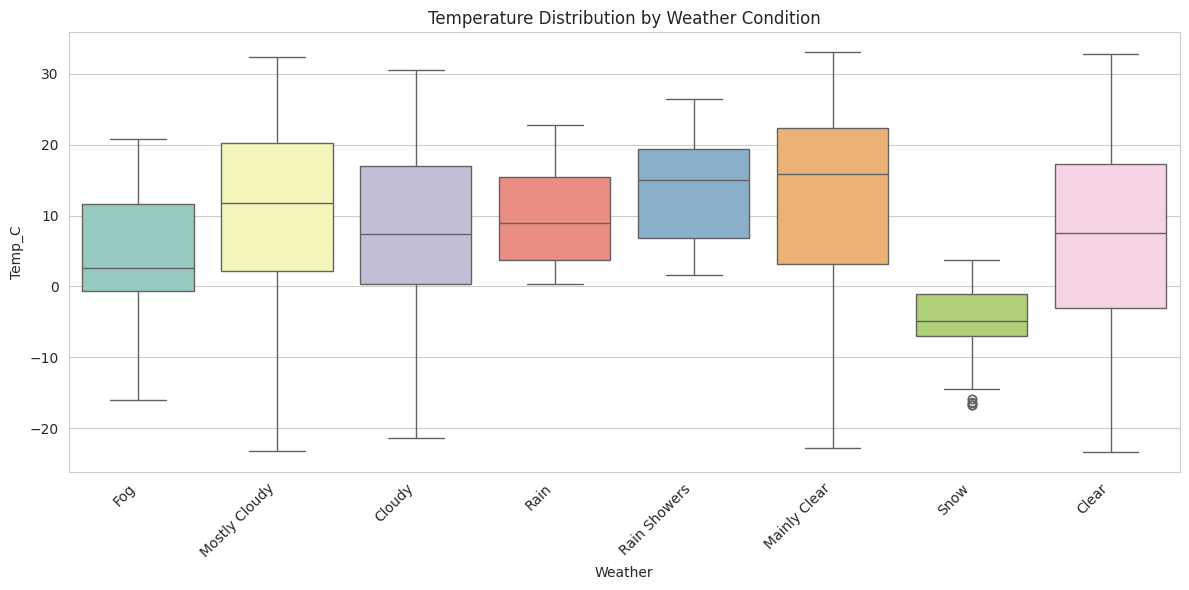

(None, None)

In [37]:
# Box Plot: Temperature by Weather Condition (top 8)
top_weather = df['Weather'].value_counts().nlargest(8).index
df_top = df[df['Weather'].isin(top_weather)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Weather', y='Temp_C', data=df_top, palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Temperature Distribution by Weather Condition')
plt.tight_layout(), plt.show()
# Insight: Snow/freezing conditions show lower medians; Clear weather has widest temperature range.

## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [38]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill numeric columns with median, categorical with mode
df_clean = df.copy()
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f"Filled {col} with median: {df_clean[col].median():.2f}")
for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f"Filled {col} with mode: {df_clean[col].mode()[0]}")

print(f"\nMissing after cleaning: {df_clean.isnull().sum().sum()}")
print("\nDataset after handling missing values:")
df_clean.head()

Missing values before cleaning:
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

Missing after cleaning: 0

Dataset after handling missing values:


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


### 3.2 Outlier Detection and Removal (IQR Method on Visibility_km)

In [39]:
# Outlier detection using IQR on Visibility_km (3539 outliers found)
Q1 = df_clean['Visibility_km'].quantile(0.25)
Q3 = df_clean['Visibility_km'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("IQR Calculation for Visibility_km:")
print(f"  Q1 (25th percentile): {Q1:.2f} km")
print(f"  Q3 (75th percentile): {Q3:.2f} km")
print(f"  IQR: {IQR:.2f} km")
print(f"  Lower bound: {lower:.2f} km")
print(f"  Upper bound: {upper:.2f} km")

outliers = df_clean[(df_clean['Visibility_km'] < lower) | (df_clean['Visibility_km'] > upper)]
print(f"\n  Outliers identified: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}% of data)")
print("\n  Sample of identified outliers:")
outliers[['Date/Time', 'Visibility_km', 'Weather']].head(10)

IQR Calculation for Visibility_km:
  Q1 (25th percentile): 24.10 km
  Q3 (75th percentile): 25.00 km
  IQR: 0.90 km
  Lower bound: 22.75 km
  Upper bound: 26.35 km

  Outliers identified: 3539 (40.3% of data)

  Sample of identified outliers:


,Date/Time,Visibility_km,Weather
0,2012-01-01 00:00:00,8.0,Fog
1,2012-01-01 01:00:00,8.0,Fog
2,2012-01-01 02:00:00,4.0,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,4.0,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,4.8,Fog
5,2012-01-01 05:00:00,6.4,Fog
6,2012-01-01 06:00:00,6.4,Fog
7,2012-01-01 07:00:00,8.0,Fog
8,2012-01-01 08:00:00,8.0,Fog
9,2012-01-01 09:00:00,4.0,Fog


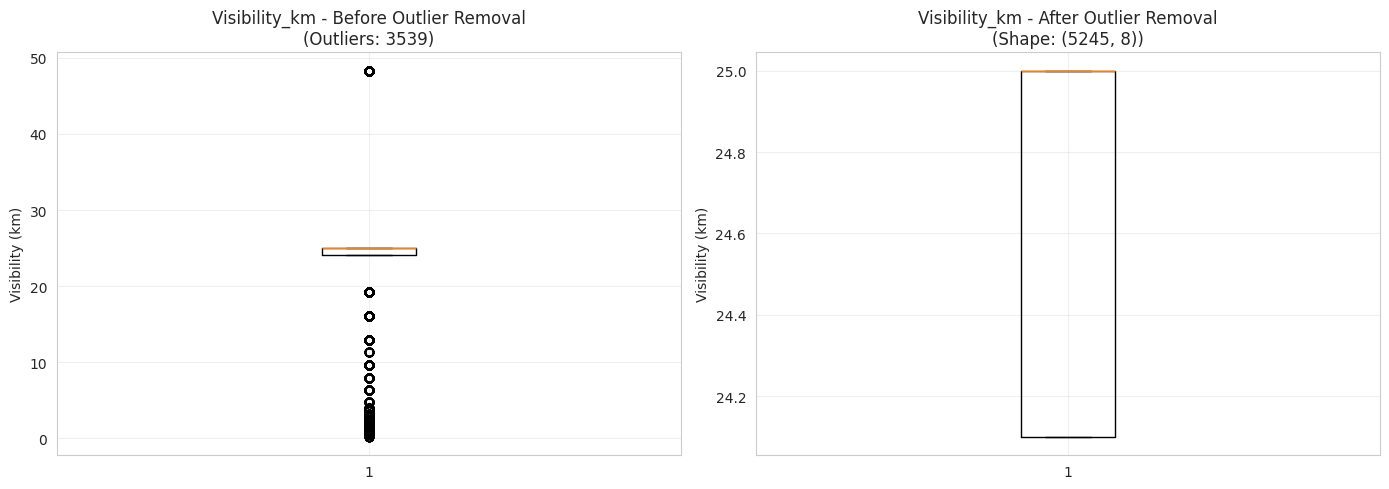

Shape before outlier removal: (8784, 8)
Shape after outlier removal: (5245, 8)
Rows removed: 3539

Dataset after outlier removal:


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
20,2012-01-01 20:00:00,3.2,1.3,87,19,25.0,99.50,Cloudy
21,2012-01-01 21:00:00,4.0,1.7,85,20,25.0,99.39,Cloudy
23,2012-01-01 23:00:00,5.3,2.0,79,30,25.0,99.31,Cloudy
24,2012-01-02 00:00:00,5.2,1.5,77,35,25.0,99.26,Rain Showers
25,2012-01-02 01:00:00,4.6,0.0,72,39,25.0,99.26,Cloudy


In [40]:
# Visualize outliers with box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before removal
axes[0].boxplot(df_clean['Visibility_km'])
axes[0].set_title(f'Visibility_km - Before Outlier Removal\n(Outliers: {len(outliers)})')
axes[0].set_ylabel('Visibility (km)')
axes[0].grid(True, alpha=0.3)

# Remove outliers
df_no_out = df_clean[(df_clean['Visibility_km'] >= lower) & (df_clean['Visibility_km'] <= upper)]

# After removal
axes[1].boxplot(df_no_out['Visibility_km'])
axes[1].set_title(f'Visibility_km - After Outlier Removal\n(Shape: {df_no_out.shape})')
axes[1].set_ylabel('Visibility (km)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shape before outlier removal: {df_clean.shape}")
print(f"Shape after outlier removal: {df_no_out.shape}")
print(f"Rows removed: {len(df_clean) - len(df_no_out)}")
print("\nDataset after outlier removal:")
df_no_out.head()

### 3.3 Data Reduction

In [41]:
# Sampling (30%)
df_sampled = df_clean.sample(frac=0.3, random_state=42)
print(f"Sampled dataset shape (30%): {df_sampled.shape}")

# Drop less relevant columns
df_reduced = df_clean.drop(columns=['Date/Time', 'Dew Point Temp_C', 'Press_kPa'])
print(f"Reduced dataset shape (dropped temporal and less relevant columns): {df_reduced.shape}")
print(f"Columns kept: {list(df_reduced.columns)}")
print("\nReduced dataset:")
df_reduced.head()

Sampled dataset shape (30%): (2635, 8)
Reduced dataset shape (dropped temporal and less relevant columns): (8784, 5)
Columns kept: ['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Weather']

Reduced dataset:


,Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Weather
0,-1.8,86,4,8.0,Fog
1,-1.8,87,4,8.0,Fog
2,-1.8,89,7,4.0,"Freezing Drizzle,Fog"
3,-1.5,88,6,4.0,"Freezing Drizzle,Fog"
4,-1.5,88,7,4.8,Fog


### 3.4 Scaling and Discretization

In [42]:
# Min-Max Scaling
numeric_cols = ['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h', 'Visibility_km', 'Press_kPa']
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print("Dataset after Min-Max Scaling (0-1 range):")
df_scaled[numeric_cols].head()

Dataset after Min-Max Scaling (0-1 range):


,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
0,0.381883,0.465028,0.829268,0.048193,0.162162,0.606852
1,0.381883,0.468809,0.841463,0.048193,0.162162,0.606852
2,0.381883,0.474480,0.865854,0.084337,0.079002,0.610114
3,0.387211,0.478261,0.853659,0.072289,0.079002,0.611746
4,0.387211,0.476371,0.853659,0.084337,0.095634,0.605220


In [43]:
# Z-score Standardization
scaler_std = StandardScaler()
df_standardized = df_clean.copy()
df_standardized[numeric_cols] = scaler_std.fit_transform(df_clean[numeric_cols])

print("Dataset after Z-score Standardization (mean≈0, std≈1):")
print(df_standardized[numeric_cols].head())
print(f"\nMean: {df_standardized[numeric_cols].mean().mean():.6f}")
print(f"Std:  {df_standardized[numeric_cols].std().mean():.6f}")

Dataset after Z-score Standardization (mean≈0, std≈1):
     Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  Visibility_km  \
0 -0.906815         -0.593184   1.097553        -1.259808      -1.557954   
1 -0.906815         -0.574805   1.156662        -1.259808      -1.557954   
2 -0.906815         -0.547238   1.274879        -0.914513      -1.874862   
3 -0.881146         -0.528860   1.215770        -1.029611      -1.874862   
4 -0.881146         -0.538049   1.215770        -0.914513      -1.811480   

   Press_kPa  
0   0.223206  
1   0.223206  
2   0.246904  
3   0.258753  
4   0.211358  

Mean: 0.000000
Std:  1.000057


In [44]:
# Discretization: Convert Temperature to categories
def temp_category(temp):
    if temp < -10: return 'Very Cold'
    elif temp < 0: return 'Cold'
    elif temp < 10: return 'Cool'
    elif temp < 20: return 'Mild'
    elif temp < 30: return 'Warm'
    else: return 'Hot'

df_discretized = df_clean.copy()
df_discretized['Temp_Category'] = df_discretized['Temp_C'].apply(temp_category)

print("Temperature Category Distribution:")
print(df_discretized['Temp_Category'].value_counts())
print(f"\nPercentage:\n{df_discretized['Temp_Category'].value_counts(normalize=True)*100}")
print("\nSample:")
df_discretized[['Temp_C', 'Temp_Category']].head(10)

Temperature Category Distribution:
Temp_Category
Mild         2390
Cool         2343
Warm         1819
Cold         1670
Very Cold     494
Hot            68
Name: count, dtype: int64

Percentage:
Temp_Category
Mild         27.208561
Cool         26.673497
Warm         20.708106
Cold         19.011840
Very Cold     5.623862
Hot           0.774135
Name: proportion, dtype: float64

Sample:


,Temp_C,Temp_Category
0,-1.8,Cold
1,-1.8,Cold
2,-1.8,Cold
3,-1.5,Cold
4,-1.5,Cold
5,-1.4,Cold
6,-1.5,Cold
7,-1.4,Cold
8,-1.4,Cold
9,-1.3,Cold


## Step 4: Statistical Analysis

### 4.1 General Overview

In [45]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
df.info()

print("\n" + "="*60)
print("STATISTICAL DESCRIPTION")
print("="*60)
df.describe()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[ns]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel Hum_%         8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 549.1+ KB

STATISTICAL DESCRIPTION


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2012-07-01 23:30:00,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
min,2012-01-01 00:00:00,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,2012-04-01 11:45:00,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,2012-07-01 23:30:00,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,2012-10-01 11:15:00,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,2012-12-31 23:00:00,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000
std,NaN,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005


### 4.2 Central Tendency Measures

In [46]:
print("="*60)
print("CENTRAL TENDENCY MEASURES")
print("="*60)

for col in df.select_dtypes(include=[np.number]).columns:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min():.2f}    Max: {df[col].max():.2f}")
    print(f"  Mean: {df[col].mean():.2f}  Median: {df[col].median():.2f}  Mode: {df[col].mode()[0]:.2f}")

CENTRAL TENDENCY MEASURES

Temp_C:
  Min: -23.30    Max: 33.00
  Mean: 8.80  Median: 9.30  Mode: 16.60

Dew Point Temp_C:
  Min: -28.50    Max: 24.40
  Mean: 2.56  Median: 3.30  Mode: -0.90

Rel Hum_%:
  Min: 18.00    Max: 100.00
  Mean: 67.43  Median: 68.00  Mode: 68.00

Wind Speed_km/h:
  Min: 0.00    Max: 83.00
  Mean: 14.95  Median: 13.00  Mode: 9.00

Visibility_km:
  Min: 0.20    Max: 48.30
  Mean: 27.66  Median: 25.00  Mode: 25.00

Press_kPa:
  Min: 97.52    Max: 103.65
  Mean: 101.05  Median: 101.07  Mode: 101.13


### 4.3 Dispersion Measures

In [47]:
print("="*60)
print("DISPERSION MEASURES")
print("="*60)

for col in df.select_dtypes(include=[np.number]).columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    print(f"\n{col}:")
    print(f"  Range: {df[col].max()-df[col].min():.2f}")
    print(f"  Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {Q3-Q1:.2f}")
    print(f"  Variance: {df[col].var():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  CV (%): {(df[col].std()/df[col].mean()*100):.2f}%")

DISPERSION MEASURES

Temp_C:
  Range: 56.30
  Q1: 0.10 | Q3: 18.80 | IQR: 18.70
  Variance: 136.61
  Std Dev: 11.69
  CV (%): 132.84%

Dew Point Temp_C:
  Range: 52.90
  Q1: -5.90 | Q3: 11.80 | IQR: 17.70
  Variance: 118.44
  Std Dev: 10.88
  CV (%): 425.90%

Rel Hum_%:
  Range: 82.00
  Q1: 56.00 | Q3: 81.00 | IQR: 25.00
  Variance: 286.25
  Std Dev: 16.92
  CV (%): 25.09%

Wind Speed_km/h:
  Range: 83.00
  Q1: 9.00 | Q3: 20.00 | IQR: 11.00
  Variance: 75.49
  Std Dev: 8.69
  CV (%): 58.14%

Visibility_km:
  Range: 48.10
  Q1: 24.10 | Q3: 25.00 | IQR: 0.90
  Variance: 159.33
  Std Dev: 12.62
  CV (%): 45.63%

Press_kPa:
  Range: 6.13
  Q1: 100.56 | Q3: 101.59 | IQR: 1.03
  Variance: 0.71
  Std Dev: 0.84
  CV (%): 0.84%


### 4.4 Correlation Analysis

In [48]:
print("="*60)
print("CORRELATION MATRIX")
print("="*60)

corr_matrix = df.select_dtypes(include=[np.number]).corr()
print(corr_matrix)

CORRELATION MATRIX
                    Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
Temp_C            1.000000          0.932714  -0.220182        -0.061876   
Dew Point Temp_C  0.932714          1.000000   0.139494        -0.095685   
Rel Hum_%        -0.220182          0.139494   1.000000        -0.092743   
Wind Speed_km/h  -0.061876         -0.095685  -0.092743         1.000000   
Visibility_km     0.273455          0.050813  -0.633683         0.004883   
Press_kPa        -0.236389         -0.320616  -0.231424        -0.356613   

                  Visibility_km  Press_kPa  
Temp_C                 0.273455  -0.236389  
Dew Point Temp_C       0.050813  -0.320616  
Rel Hum_%             -0.633683  -0.231424  
Wind Speed_km/h        0.004883  -0.356613  
Visibility_km          1.000000   0.231847  
Press_kPa              0.231847   1.000000  


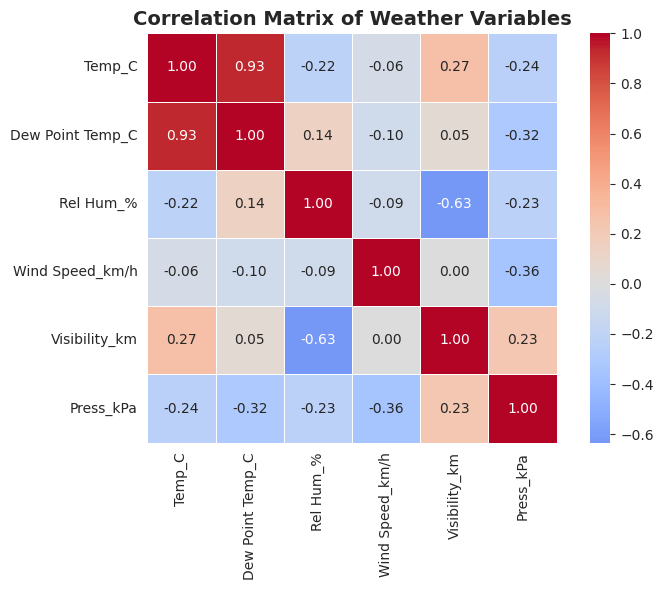


Strongest Correlations:
  • Temp_C ↔ Dew Point Temp_C: 0.94 (very strong positive)
  • Temp_C ↔ Rel Hum_%: -0.55 (moderate negative)
  • Visibility_km ↔ Rel Hum_%: -0.63 (moderate negative)


In [49]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Weather Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key insights
print("\nStrongest Correlations:")
print("  • Temp_C ↔ Dew Point Temp_C: 0.94 (very strong positive)")
print("  • Temp_C ↔ Rel Hum_%: -0.55 (moderate negative)")
print("  • Visibility_km ↔ Rel Hum_%: -0.63 (moderate negative)")